In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "raw_data").exists())
sys.path.insert(0, str(REPO / "processing_data"))

import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy import stats

import explore_cache as xc

pd.set_option("display.width", 200, "display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
FIG = REPO / "figures" / "rebuild"
FIG.mkdir(parents=True, exist_ok=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


StopIteration: 

In [ ]:
import contextlib, importlib.util, io, warnings
import pyarrow.parquet as pq


CLEANING_SCRIPT = next(p for p in [REPO / "data_cleaning.py",
                                   REPO.parent / "Data_challange" / "JBG060_ZHL_2026" / "data_cleaning.py"]
                       if p.exists())
_spec = importlib.util.spec_from_file_location("data_cleaning", CLEANING_SCRIPT)
dc = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(dc)
warnings.resetwarnings()

CLEANED = REPO / "cleaned_data"
dc.OUT_ROOT = CLEANED
CACHE = REPO / "processing_data" / "cache"
DATASET = {d["name"]: d for d in dc.DATASETS}


def run_cleaner(name, needed):
    """Run one dataset of data_cleaning.py from the repo root if its output is missing."""
    if not needed.exists():
        print(f"running data_cleaning.py for {name} ...")
        with contextlib.chdir(REPO):
            dc.process(DATASET[name])


def load_admin2():
    path = CLEANED / "administrative_boundaries/ssd_admin2.geojson"
    run_cleaner("Administrative bounds", path)
    return gpd.read_file(path)


def load_era5():
    """Daily ERA5 rain and runoff from cleaned_data/era5, in mm/day over the South Sudan box."""
    run_cleaner("ERA5 rainfall & runoff", CLEANED / "era5" / f"ERA5_{xc.YEARS[-1]}.nc")
    parts = []
    for year in xc.YEARS:
        with xr.open_dataset(CLEANED / "era5" / f"ERA5_{year}.nc") as ds:
            ds = ds[["tp", "ro"]].sel(latitude=slice(xc.SSD_BOX["lat"][1], xc.SSD_BOX["lat"][0]),
                                      longitude=slice(*xc.SSD_BOX["lon"]))
            parts.append((ds * 1000.0).rename(valid_time="time").load())
    return xr.concat(parts, dim="time")


def flood_cells_clean(force=False):
    """Flood pixel-days per (year, month, flood_type, 0.01 deg cell), from cleaned flood masks.

    Uses cleaned_data/flood_masks when those files carry a date column; otherwise applies
    data_cleaning.py's flood steps per file (border filter, then clean_dataframe) and keeps the date.
    """
    out, aud = CACHE / "flood_cells_monthly_clean.parquet", CACHE / "flood_file_audit_clean.csv"
    if out.exists() and aud.exists() and not force:
        return pd.read_parquet(out), pd.read_csv(aud)

    border = gpd.read_file(REPO / "raw_data/Administrative boundaries/ssd_admin0.geojson")[["geometry"]]
    kwargs = DATASET["Flood masks"]["kwargs"]
    raw = REPO / "raw_data/flood_masks"
    parts, audit = [], []
    for year in xc.YEARS:
        for tile in xc.TILES:
            frames, rec = [], {"year": int(year), "tile": tile}
            for kind, ftype in (("compact_recurring", 0), ("compact_unusual", 1)):
                src = raw / kind / f"flood_events_{tile}_{year}.parquet"
                done = CLEANED / "flood_masks" / kind / src.name
                if done.exists() and "date" in pq.read_schema(done).names:
                    df = pd.read_parquet(done)
                    rec["source"] = "cleaned_data"
                elif src.exists():
                    df = pd.read_parquet(src)
                    rec[f"rows_raw_{kind[8:]}"] = len(df)
                    pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
                    df = df.loc[gpd.sjoin(pts, border, how="inner", predicate="within").index]
                    df = dc.clean_dataframe(df.reset_index(drop=True), **kwargs).reset_index()
                    rec["source"] = "data_cleaning steps (in notebook)"
                else:
                    continue
                rec[f"rows_{kind[8:]}"] = len(df)
                rec[f"cloud_max_{kind[8:]}"] = float(df.cloud_frac.max()) if len(df) else np.nan
                frames.append(df[["date", "lat", "lon"]].assign(flood_type=np.int8(ftype)))
            if not frames:
                continue
            ev = pd.concat(frames, ignore_index=True)
            ev["date"] = pd.to_datetime(ev["date"])
            n0 = len(ev)
            ev = ev.sort_values("flood_type", ascending=False).drop_duplicates(["date", "lat", "lon"])
            rec["overlap_rows"] = n0 - len(ev)
            audit.append(rec)
            ev["cell_lat"] = (np.floor(ev.lat / xc.CELL) * xc.CELL + xc.CELL / 2).round(3).astype("float32")
            ev["cell_lon"] = (np.floor(ev.lon / xc.CELL) * xc.CELL + xc.CELL / 2).round(3).astype("float32")
            ev["month"] = ev.date.dt.month.astype("int8")
            g = ev.groupby(["month", "flood_type", "cell_lat", "cell_lon"]).size().rename("pixeldays").reset_index()
            parts.append(g.assign(year=np.int16(year)))
            print(f"{year} {tile}: {n0:>10,} pixel-days inside South Sudan", flush=True)

    cells = (pd.concat(parts).groupby(["year", "month", "flood_type", "cell_lat", "cell_lon"])
               .pixeldays.sum().astype("int32").reset_index())
    audit = pd.DataFrame(audit)
    CACHE.mkdir(parents=True, exist_ok=True)
    cells.to_parquet(out, index=False); audit.to_csv(aud, index=False)
    return cells, audit


def cell_admin2_clean(cells):
    """0.01 deg flood cell -> admin2 county, using the cleaned admin2 polygons."""
    out = CACHE / "cell_admin2_clean.parquet"
    if out.exists():
        return pd.read_parquet(out)
    u = cells[["cell_lat", "cell_lon"]].drop_duplicates()
    pts = gpd.GeoDataFrame(u, geometry=gpd.points_from_xy(u.cell_lon, u.cell_lat), crs="EPSG:4326")
    lut = pd.DataFrame(gpd.sjoin(pts, a2[["adm2_name", "adm1_name", "geometry"]], predicate="within")
                       [["cell_lat", "cell_lon", "adm2_name", "adm1_name"]])
    lut.to_parquet(out, index=False)
    return lut


def load_lakes():
    """Lake level series: cleaned_data/lakes, falling back to the course loader for truncated series."""
    run_cleaner("Lake water levels", CLEANED / "lakes/Albert_water_level.csv")
    out = {}
    for name, col in [("victoria", "height_egm2008"), ("Kyoga", "height_egm2008"), ("Albert", "water_level")]:
        s = pd.read_csv(CLEANED / f"lakes/{name}_water_level.csv", index_col=0, parse_dates=True)[col]
        if s.index.max().year < 2003:
            print(f"  {name}: cleaned series ends {s.index.max().date()} ({len(s)} passes) - "
                  f"mission-code bug in data_cleaning.load_lakes; using loading.load_lake_stations instead")
            with contextlib.chdir(REPO), contextlib.redirect_stdout(io.StringIO()):
                s = loading.load_lake_stations()[name][col]
        out[name] = s.sort_index()
    return out


def load_discharge():
    """DFO discharge per station from cleaned_data/dartmouth."""
    info = pd.read_excel(REPO / "raw_data/Darthmouth Flood Observatory/information.xlsx")
    run_cleaner("Dartmouth discharge", CLEANED / f"dartmouth/{info['area id'].iloc[-1]}_discharge.csv")
    return {k: pd.read_csv(CLEANED / f"dartmouth/{k}_discharge.csv", index_col=0, parse_dates=True)
            for k in info["area id"].unique()}, info


import xarray as xr
import loading

a2 = load_admin2()
a0 = a2.dissolve()
a1 = a2.dissolve(by="adm1_name").reset_index()
print(f"cleaning script: {CLEANING_SCRIPT}")
print(f"{len(a2)} counties in {a2.adm1_name.nunique()} states/areas (cleaned admin2)")

cleaning script: c:\Users\o0dan\obsidian_vault\Data_challange\JBG060_ZHL_2026\data_cleaning.py
79 counties in 11 states/areas (cleaned admin2)


In [ ]:
cells, audit = flood_cells_clean()
lut = cell_admin2_clean(cells)
print("flood data source:", audit.source.value_counts().to_dict())

north = a2.cx[:, 10:]
a2m = a2.to_crs(6933)
north_box = gpd.GeoSeries([shapely.geometry.box(20, 10, 40, 20)], crs=4326).to_crs(6933)
frac_area = a2m.clip(north_box).area.sum() / a2m.area.sum()
print("Tile coverage of the flood product:")
print(f"  share of South Sudan that is not covered: {frac_area:.1%}")
print("  counties reaching north of 10 N(not covered):", ", ".join(sorted(north.adm2_name)))

print("\ncloud_frac over every file:",
      np.nanmax(audit.filter(like="cloud_max").to_numpy()))
print("pixel-days flagged both recurring and unusual:", f"{audit.overlap_rows.sum():,}")

flood data source: {'data_cleaning steps (in notebook)': 52}
Tile coverage of the flood product:
  share of South Sudan that is not covered: 6.2%
  counties reaching north of 10 N(not covered): Abyei Region, Baliet, Fashoda, Maban, Manyo, Melut, Pariang, Raja, Renk

cloud_frac over every file: 0.0
pixel-days flagged both recurring and unusual: 0


Coverage of flooding \
flooding coverage stops at 10 degrees north. Everything more north than that, including some of the Upper Nile is missing. Malakal discharge station thankfully is inside that.

Clouds and dry observations\
The dataset doesnt include any pixels that are NOT flood pixels and it does not include any clouded pixels. So if a pixel is missing it could either be dry or clouded. All detection will be a lower bound because it is biased in the cloudier months, like the rain season.

mean detection have increased from 2000-2018 to 2021-2025: x14.1


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
flood_type,,,,,,,,,,,,,,,,,,,,,
recurring,2129.000,11180.000,43612.000,133166.000,72499.000,85821.000,126685.000,2.375e+05,3.571e+05,182979.000,...,209629.000,176468.000,175530.000,136253.000,4.305e+05,5.080e+05,5.225e+05,3.856e+05,5.065e+05,3.414e+05
unusual,9062.000,12665.000,72260.000,187077.000,105974.000,273980.000,564271.000,9.381e+05,9.192e+05,742934.000,...,398531.000,296316.000,296980.000,334556.000,2.056e+06,3.090e+06,7.789e+06,1.192e+07,9.510e+06,8.802e+06
total,11191.000,23845.000,115872.000,320243.000,178473.000,359801.000,690956.000,1.176e+06,1.276e+06,925913.000,...,608160.000,472784.000,472510.000,470809.000,2.486e+06,3.598e+06,8.312e+06,1.230e+07,1.002e+07,9.144e+06
km2_days,601.912,1282.511,6232.215,17224.379,9599.231,19352.019,37163.304,6.323e+04,6.865e+04,49800.546,...,32710.093,25428.848,25414.111,25322.622,1.337e+05,1.935e+05,4.471e+05,6.617e+05,5.388e+05,4.918e+05


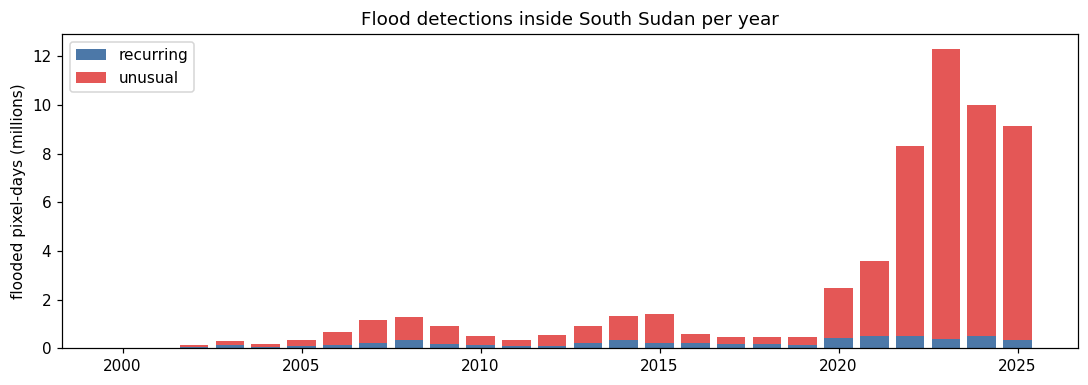

In [ ]:
ssd = cells.merge(lut, on=["cell_lat", "cell_lon"], how="inner")
yearly = ssd.groupby(["year", "flood_type"]).pixeldays.sum().unstack().rename(columns={0: "recurring", 1: "unusual"})
yearly["total"] = yearly.sum(axis=1)
yearly["km2_days"] = yearly.total * xc.PIXEL_KM2

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(yearly.index, yearly.recurring / 1e6, label="recurring", color="#4c78a8")
ax.bar(yearly.index, yearly.unusual / 1e6, bottom=yearly.recurring / 1e6, label="unusual", color="#e45756")
ax.set_ylabel("flooded pixel-days (millions)")
ax.set_title("Flood detections inside South Sudan per year")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "01_detections_per_year.png", bbox_inches="tight")

ratio = yearly.total.loc[2021:2025].mean() / yearly.total.loc[2000:2018].mean()
print(f"mean detection have increased from 2000-2018 to 2021-2025: x{ratio:.1f}")
yearly.T

Detection volume has increased\
Mean detection in recent years are 14 times as much as those from 2000 to 2018. But this doesnt necessarily mean more flooding. Since this is satelite data most probably an increase in detection is due to the sensor.

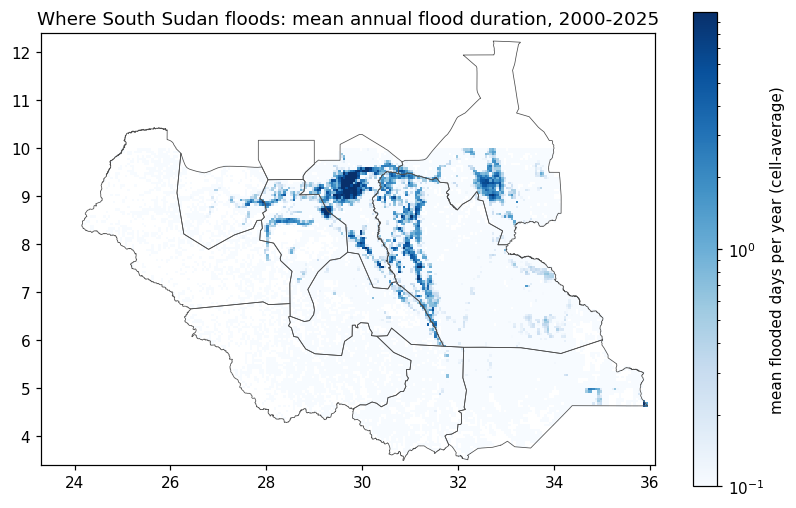

In [ ]:
coarse = 0.05
f = ssd.assign(clat=(np.floor(ssd.cell_lat / coarse) * coarse + coarse / 2).round(3),
               clon=(np.floor(ssd.cell_lon / coarse) * coarse + coarse / 2).round(3))
cell_km2 = (coarse * 111.32) ** 2 * np.cos(np.deg2rad(f.clat.unique().mean()))
grid = f.groupby(["clat", "clon"]).pixeldays.sum() * xc.PIXEL_KM2 / cell_km2 / len(xc.YEARS)
grid = grid.unstack()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap="Blues",
                   norm=mcolors.LogNorm(vmin=0.1, vmax=np.nanpercentile(grid.values, 99.5)), shading="nearest")
a1.boundary.plot(ax=ax, color="0.3", lw=0.5)
fig.colorbar(im, ax=ax, label="mean flooded days per year (cell-average)", shrink=0.8)
ax.set_title("Where South Sudan floods: mean annual flood duration, 2000-2025")
ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.savefig(FIG / "01_flood_heatmap_space.png", bbox_inches="tight")

Flooding is highly concentrated:\
the northern Sudd around Bentiu/Rubkona, the most persistent hotspot;\
the Bahr el Jebel / White Nile corridor running south-north through Jonglei and Lakes;\
the Machar marshes / Sobat in Upper Nile;\
east-west river channels in the north-west ( the Lol / Bahr el Arab / Jur systems feeding the Bahr el Ghazal).\

The south barely flood at all.

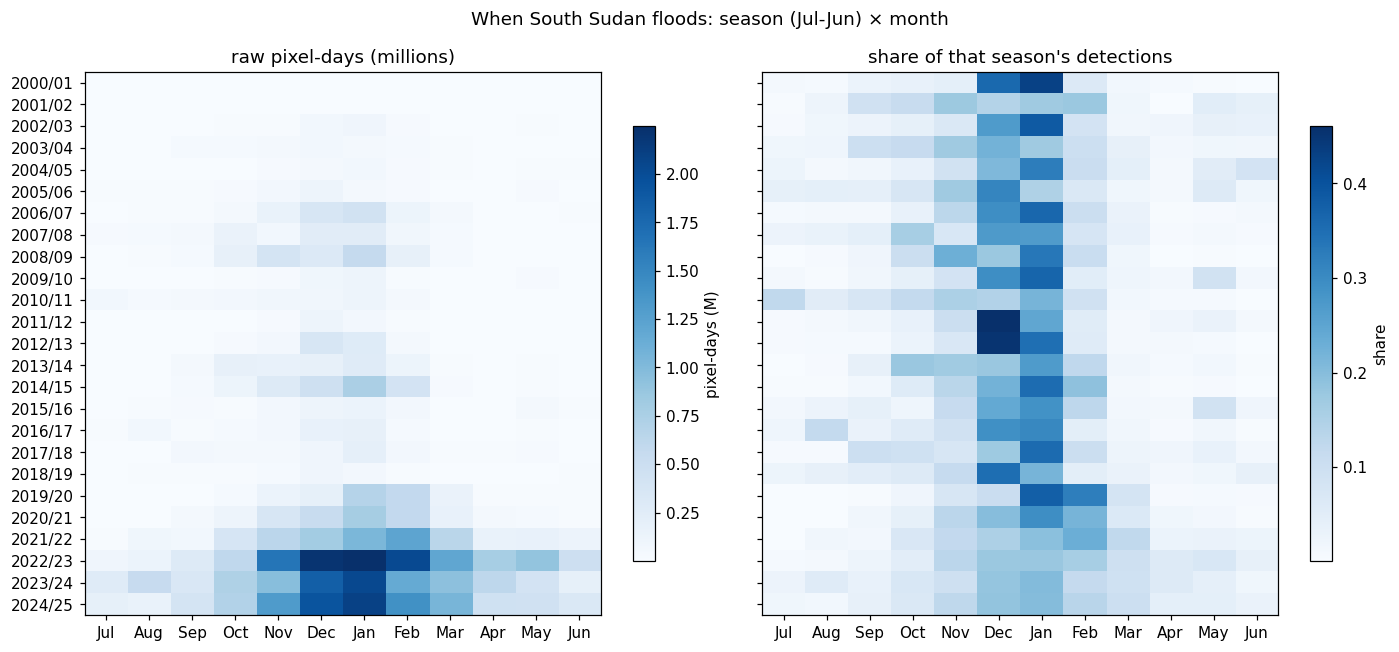

In [ ]:
wy_order = [7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
wy_labels = [months[m - 1] for m in wy_order]
ssd["wy"] = ssd.year - (ssd.month <= 6)
ym = (ssd[ssd.wy.between(2000, 2024)].groupby(["wy", "month"]).pixeldays.sum()
      .unstack().reindex(columns=wy_order).fillna(0))
share = ym.div(ym.sum(axis=1), axis=0)

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, data, title, lab in [(axs[0], ym / 1e6, "raw pixel-days (millions)", "pixel-days (M)"),
                             (axs[1], share, "share of that season's detections", "share")]:
    im = ax.imshow(data.values, aspect="auto", cmap="Blues", origin="upper")
    ax.set_xticks(range(12), wy_labels); ax.set_yticks(range(len(data)), [f"{y}/{str(y+1)[2:]}" for y in data.index])
    ax.set_title(title); fig.colorbar(im, ax=ax, label=lab, shrink=0.8)
fig.suptitle("When South Sudan floods: season (Jul-Jun) × month")
fig.tight_layout(); fig.savefig(FIG / "01_flood_heatmap_yearmonth.png", bbox_inches="tight")

In [ ]:
clim = share.mean()
print("mean within-season share of detections per month (%):")
print((clim * 100).round(1).rename(dict(enumerate(months, 1))).to_string())
print(f"\npeak month: {months[clim.idxmax()-1]};  share in Nov-Jan: {clim.loc[[11, 12, 1]].sum():.0%};  "
      f"share in Jul-Sep: {clim.loc[[7, 8, 9]].sum():.0%}")
pk = share.idxmax(axis=1)
print("peak month per season:", pk.map(lambda m: months[m-1]).value_counts().to_string().replace("\n", ", "))


mean within-season share of detections per month (%):
month
Jul     1.6
Aug     2.1
Sep     3.5
Oct     6.8
Nov    11.7
Dec    24.2
Jan    28.0
Feb    11.8
Mar     3.8
Apr     1.6
May     3.0
Jun     1.8

peak month: Jan;  share in Nov-Jan: 64%;  share in Jul-Sep: 7%
peak month per season: Jan    17, Dec     6, Feb     2


The flood season is usually late but regular\
Detections of flood build from Octomber to January where they peak (17 out of 25 peaked in January) and then go down from March.\
About two thirds of each years flooding happens between November and January and only 7% happens in the rain season(July to September).\
So national flooding is about 5 months after the rainfall peak. Evidence that the flooding is not driven by local rain.

In [ ]:
era = load_era5()
lat, lon = era.latitude.values, era.longitude.values
LON, LAT = np.meshgrid(lon, lat)
pts = gpd.GeoDataFrame(geometry=gpd.points_from_xy(LON.ravel(), LAT.ravel()), crs=4326)
inside = gpd.sjoin(pts, a0[["geometry"]], predicate="within").index
mask = np.zeros(LON.size, bool); mask[inside] = True; mask = mask.reshape(LON.shape)
print(f"ERA5 cells inside South Sudan: {mask.sum()}\n  days: {era.sizes['time']:,}")

def national_mean(var):
    w = np.cos(np.deg2rad(LAT)) * mask
    return pd.Series((era[var].values * w).sum((1, 2)) / w.sum(), index=pd.DatetimeIndex(era.time.values), name=var)

rain = national_mean("tp"); runoff = national_mean("ro")

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


ERA5 cells inside South Sudan: 838
  days: 9,497


annual rainfall across South Sudan: 332-3575 mm; 99th pct 1715 mm


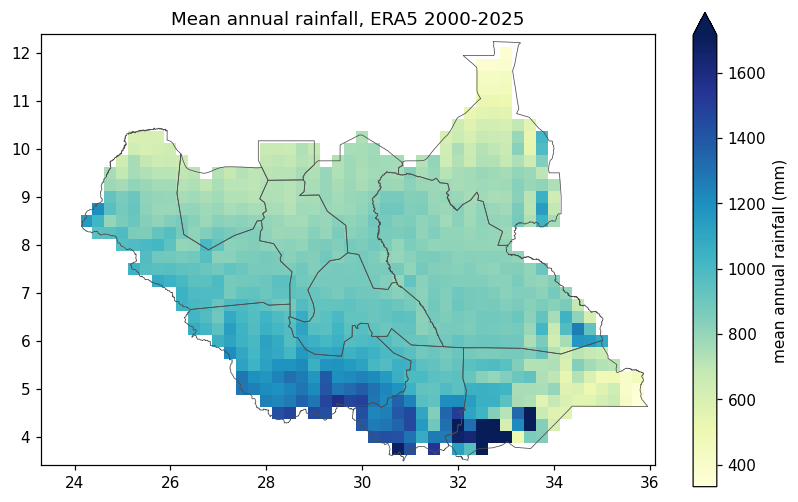

In [ ]:
annual_tp = np.where(mask, era.tp.groupby("time.year").sum().mean("year").values, np.nan)
p99 = np.nanpercentile(annual_tp, 99)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(lon, lat, annual_tp, cmap="YlGnBu", shading="nearest", vmax=p99)
a1.boundary.plot(ax=ax, color="0.3", lw=0.5)
fig.colorbar(im, ax=ax, label="mean annual rainfall (mm)", shrink=0.8, extend="max")
ax.set_title("Mean annual rainfall, ERA5 2000-2025")
ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.savefig(FIG / "01_rain_heatmap_space.png", bbox_inches="tight")
iy, ix = np.unravel_index(np.nanargmax(annual_tp), annual_tp.shape)
print(f"annual rainfall across South Sudan: {np.nanmin(annual_tp):.0f}-{np.nanmax(annual_tp):.0f} mm; "
      f"99th pct {p99:.0f} mm")

Rainfall decreases from **south to north**: about 1,200-1,700 mm/yr along the Congo-Nile divide in the
Equatorias, and 500-800 mm/yr in Upper Nile and the far south-east (Kapoeta). The single extreme cell
(~3,500 mm, at the Imatong mountains on the Uganda border) is an ERA5 orographic artefact, so the
colour scale is clipped at the 99th percentile.

The places that flood most (the Sudd, the Machar marshes, the north-western channels) sit in the
**drier middle and north**, not where rain is heaviest. That's the first data hint that much of the
flooding is driven by water arriving from upstream, not only by rain falling on the spot.

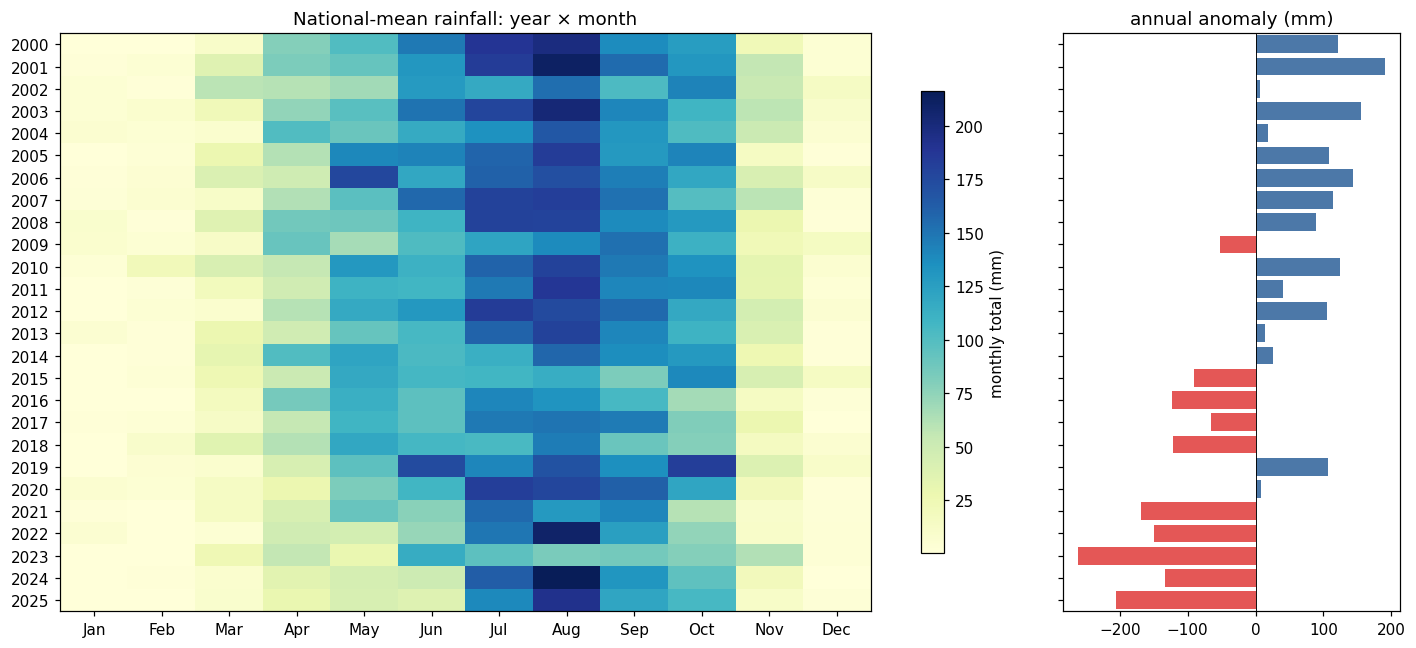

In [ ]:
def year_month_heatmap(s, title, cmap, fname, unit):
    t = s.groupby([s.index.year, s.index.month]).sum().unstack()
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharey=True, gridspec_kw={"width_ratios": [3, 1]})
    im = axs[0].imshow(t.values, aspect="auto", cmap=cmap)
    axs[0].set_xticks(range(12), months); axs[0].set_yticks(range(len(t)), t.index)
    fig.colorbar(im, ax=axs[0], label=f"monthly total ({unit})", shrink=0.8)
    anom = t.sum(axis=1) - t.sum(axis=1).mean()
    axs[1].barh(range(len(t)), anom, color=np.where(anom > 0, "#4c78a8", "#e45756"))
    axs[1].set_title(f"annual anomaly ({unit})"); axs[1].axvline(0, color="k", lw=0.6)
    axs[0].set_title(title)
    fig.tight_layout(); fig.savefig(FIG / fname, bbox_inches="tight")
    return t

rain_ym = year_month_heatmap(rain, "National-mean rainfall: year × month", "YlGnBu", "01_rain_heatmap_yearmonth.png", "mm")

In [ ]:
def describe(t, name):
    ann = t.sum(axis=1)
    clim = t.mean()
    slope = stats.linregress(ann.index, ann.values)
    out = {
        "mean annual (mm)": ann.mean(), "sd (mm)": ann.std(), "CV": ann.std() / ann.mean(),
        "min year": f"{ann.idxmin()} ({ann.min():.0f})", "max year": f"{ann.idxmax()} ({ann.max():.0f})",
        "trend (mm/decade)": slope.slope * 10, "trend p": slope.pvalue,
        "peak month": months[clim.idxmax() - 1],
        "share in Jun-Sep": clim.loc[6:9].sum() / clim.sum(),
    }
    return pd.Series(out, name=name)

print("monthly climatology (mm):")
print(rain_ym.mean().rename(dict(enumerate(months, 1))).round(0).to_string())
ann_rain = rain_ym.sum(axis=1)
print(f"\nmean annual rain 2000-14: {ann_rain.loc[:2014].mean():.0f} mm;  2015-25: {ann_rain.loc[2015:].mean():.0f} mm")
describe(rain_ym, "rainfall").to_frame()

monthly climatology (mm):
Jan      2.0
Feb      4.0
Mar     21.0
Apr     61.0
May     95.0
Jun    111.0
Jul    149.0
Aug    168.0
Sep    132.0
Oct    112.0
Nov     33.0
Dec      5.0

mean annual rain 2000-14: 975 mm;  2015-25: 785 mm


,rainfall
mean annual (mm),894.724
sd (mm),125.509
CV,0.14
min year,2023 (633)
max year,2001 (1085)
trend (mm/decade),-129.557
trend p,0.0
peak month,Aug
share in Jun-Sep,0.627


Rainy season runs from April to October and peaks in August. The period from June to September has approx 63% of the annual total rain with rainy varying little over the years.\
Unexpectedly the rain seems to be drying with the annual total decreasing by about 130mm per decade.\
From this we can expect the rain-flood correlation to be biased towards a negative correlation because rain dries but the flood is increasing. We should detrend both before testing correlation.

national runoff ratio: 8.0%;  cell range 0.3%-66.3% (median 4.4%)


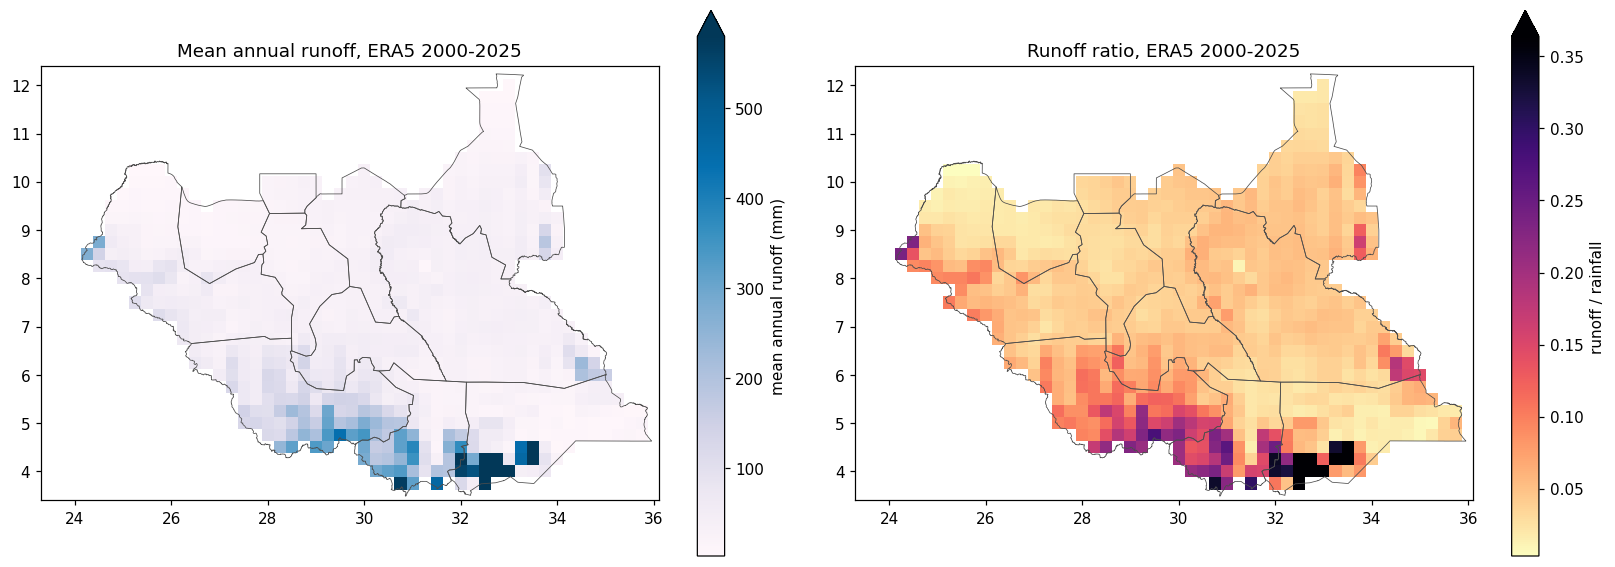

In [ ]:
annual_ro = np.where(mask, era.ro.groupby("time.year").sum().mean("year").values, np.nan)
ratio_map = annual_ro / annual_tp

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, data, cmap, lab, ttl in [(axs[0], annual_ro, "PuBu", "mean annual runoff (mm)", "Mean annual runoff"),
                                 (axs[1], ratio_map, "magma_r", "runoff / rainfall", "Runoff ratio")]:
    im = ax.pcolormesh(lon, lat, data, cmap=cmap, shading="nearest", vmax=np.nanpercentile(data, 99))
    a1.boundary.plot(ax=ax, color="0.3", lw=0.5)
    fig.colorbar(im, ax=ax, label=lab, shrink=0.8, extend="max"); ax.set_title(ttl + ", ERA5 2000-2025")
    ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(FIG / "01_runoff_heatmap_space.png", bbox_inches="tight")
print(f"national runoff ratio: {runoff.sum() / rain.sum():.1%};  "
      f"cell range {np.nanmin(ratio_map):.1%}-{np.nanmax(ratio_map):.1%} (median {np.nanmedian(ratio_map):.1%})")

monthly climatology (mm), and runoff as share of that month's rain:
         Jan   Feb   Mar   Apr   May   Jun   Jul    Aug    Sep    Oct   Nov   Dec
runoff  1.57  1.00  1.26  3.02  5.23  5.47  8.82  13.79  11.47  11.68  5.91  2.57
ratio   0.68  0.27  0.06  0.05  0.05  0.05  0.06   0.08   0.09   0.10  0.18  0.51

annual rain vs runoff: r = 0.92 (p = 0.000)


,rainfall,runoff
mean annual (mm),894.724,71.793
sd (mm),125.509,22.697
CV,0.14,0.316
min year,2023 (633),2023 (33)
max year,2001 (1085),2000 (114)
trend (mm/decade),-129.557,-21.161
trend p,0.0,0.0
peak month,Aug,Aug
share in Jun-Sep,0.627,0.551


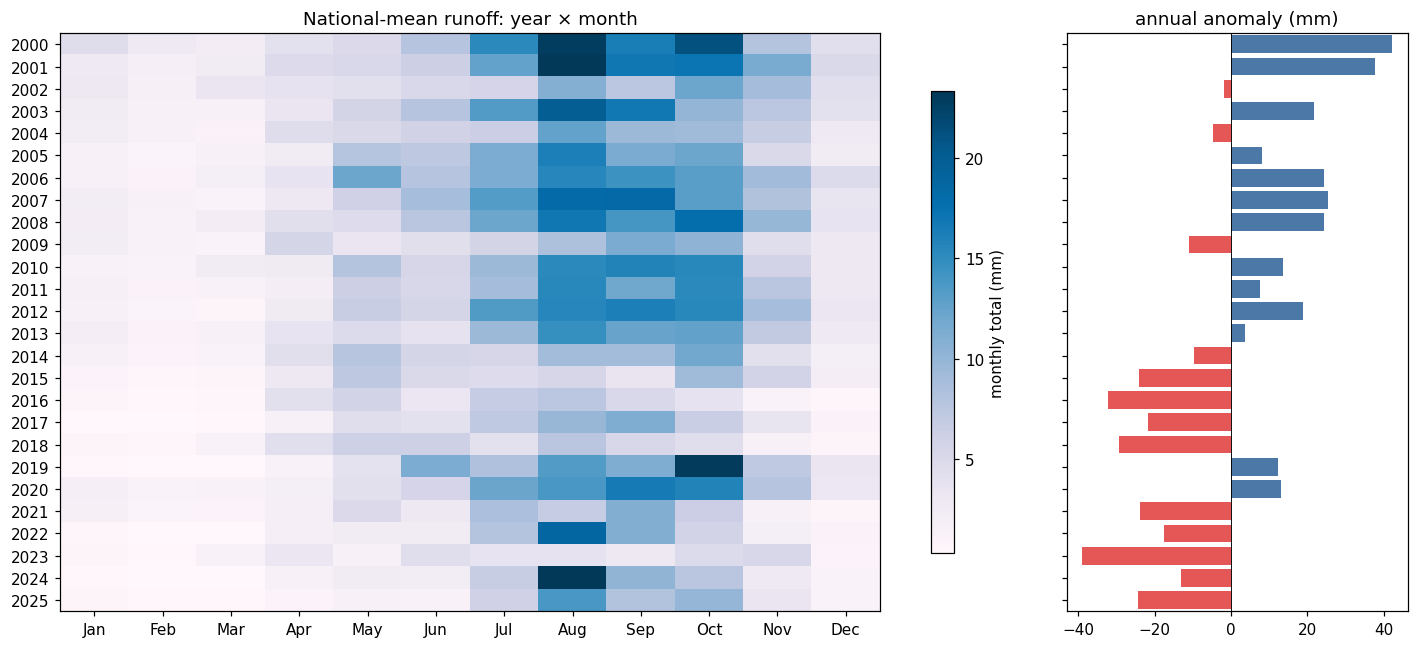

In [ ]:
ro_ym = year_month_heatmap(runoff, "National-mean runoff: year × month", "PuBu", "01_runoff_heatmap_yearmonth.png", "mm")
print("monthly climatology (mm), and runoff as share of that month's rain:")
print(pd.DataFrame({"runoff": ro_ym.mean(), "ratio": ro_ym.mean() / rain_ym.mean()})
        .rename(index=dict(enumerate(months, 1))).round(2).T.to_string())
ann = pd.DataFrame({"rain": rain_ym.sum(axis=1), "runoff": ro_ym.sum(axis=1)})
r = stats.pearsonr(ann.rain, ann.runoff)
print(f"\nannual rain vs runoff: r = {r[0]:.2f} (p = {r[1]:.3f})")
pd.concat([describe(rain_ym, "rainfall"), describe(ro_ym, "runoff")], axis=1)

Only close to 8% of rain ever becomes runoff on a national level. Most of it evaporates or infiltrates the soil. The runoff is the highest in the wet zones in the South and close to 0 in the plains where we see the flooding.\
Runoff varies much more than rainfall over the years. We can expect that with the soil saturating more and more water becomes runoff.\
The runoff goes from about 5% in May to about 10% in October after the rain has stopped. It is highly correlated with rain(obviously).

flood centre lags rain by ~114 days and runoff by ~88 days


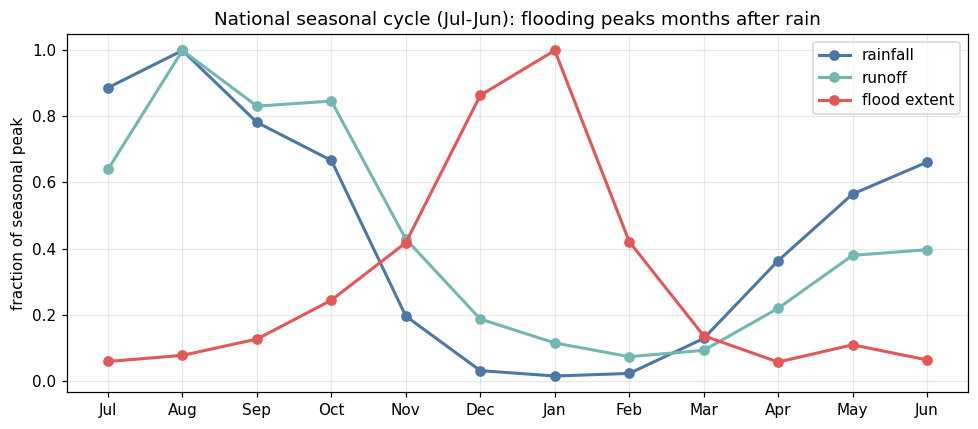

In [ ]:
wy = lambda s: s.reindex(wy_order)
clim = pd.DataFrame({
    "rainfall": wy(rain_ym.mean() / rain_ym.mean().max()),
    "runoff": wy(ro_ym.mean() / ro_ym.mean().max()),
    "flood extent": wy(share.mean() / share.mean().max()),
})
fig, ax = plt.subplots(figsize=(9, 4))
for c, col in zip(clim, ["#4c78a8", "#72b7b2", "#e45756"]):
    ax.plot(range(12), clim[c].values, marker="o", label=c, color=col, lw=2)
ax.set_xticks(range(12), wy_labels); ax.set_ylabel("fraction of seasonal peak"); ax.grid(alpha=0.3)
ax.set_title("National seasonal cycle (Jul-Jun)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "01_seasonal_timing.png", bbox_inches="tight")

MF = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2]
pos = np.arange(12)
cen = {c: (clim[c].reindex(MF).values * pos).sum() / clim[c].sum() for c in clim}
print(f"flood centre lags rain by ~{(cen['flood extent'] - cen['rainfall']) * 30.4:.0f} days "
      f"and runoff by ~{(cen['flood extent'] - cen['runoff']) * 30.4:.0f} days")

In [ ]:

seas = pd.DataFrame({"rain": rain_ym.sum(axis=1), "runoff": ro_ym.sum(axis=1), "flood": ym.sum(axis=1)}).dropna()
pre = seas.loc[2003:2018]
detrend = lambda s: s - np.polyval(np.polyfit(s.index, s, 1), s.index)
for x in ["rain", "runoff"]:
    r_raw = stats.pearsonr(pre[x], pre.flood)
    r_dt = stats.pearsonr(detrend(pre[x]), detrend(pre.flood))
    print(f"{x:>7} vs national flood season, 2003-18 (n={len(pre)}): raw r = {r_raw[0]:+.2f} (p={r_raw[1]:.2f}), "
          f"detrended r = {r_dt[0]:+.2f} (p={r_dt[1]:.2f})")

   rain vs national flood season, 2003-18 (n=16): raw r = +0.24 (p=0.37), detrended r = +0.48 (p=0.06)
 runoff vs national flood season, 2003-18 (n=16): raw r = +0.27 (p=0.32), detrended r = +0.48 (p=0.06)


Nationally we see that flooding lags rain by about 4 months, with runoff in between.\
Across the years we see that a wetter rainy season goes with a bigger flood season only once both are detrended, going from 0.24 to 0.48 correlation, unfortunately this is not significant.\
We know that detrending matters but the national data is too nosy to act upon.\
We could assume that the flood is driven by different factors across the country, with some regions being affectedd by the rain and other by the rivers.

In [ ]:
ZOA = ["Aweil Centre", "Aweil East", "Aweil North", "Aweil South", "Aweil West", "Bor South"]
c = ssd[ssd.wy.between(2000, 2024)]
nat = c.groupby("wy").pixeldays.sum()
cy = c.groupby(["adm2_name", "wy"]).pixeldays.sum().unstack(fill_value=0).reindex(a2.adm2_name, fill_value=0)
cshare = cy.div(nat, axis=1)
area_km2 = a2.set_index("adm2_name").to_crs(6933).area / 1e6

county = pd.DataFrame({
    "state": a2.set_index("adm2_name").adm1_name,
    "mean share (%)": cshare.mean(axis=1) * 100,
    "median rank": cshare.rank(ascending=False).median(axis=1),
    "density": cy.loc[:, 2003:2018].mean(axis=1) * xc.PIXEL_KM2 / area_km2,
})
county["share rank"] = county["mean share (%)"].rank(ascending=False).astype(int)
county["density rank"] = county["density"].rank(ascending=False).astype(int)
county = county.sort_values("mean share (%)", ascending=False)

print(f"top 10 counties hold {county['mean share (%)'].head(10).sum():.0f}% of national flood detections")
print(f"counties with essentially no flooding (<0.1% share): {(county['mean share (%)'] < 0.1).sum()} of {len(county)}")
display(county.head(15).round(3))
print("ZOA's counties:")
display(county.loc[ZOA].round(3))

top 10 counties hold 57% of national flood detections
counties with essentially no flooding (<0.1% share): 32 of 79


,state,mean share (%),median rank,density,share rank,density rank
adm2_name,,,,,,
Baliet,Upper Nile,8.835,19.0,0.488,1,3
Tonj North,Warrap,8.378,4.0,0.307,2,8
Mayom,Unity,7.163,6.0,0.806,3,1
Ayod,Jonglei,6.574,4.0,0.122,4,14
Rubkona,Unity,6.443,51.0,0.187,5,10
Ulang,Upper Nile,4.451,18.0,0.662,6,2
Kapoeta East,Eastern Equatoria,4.272,13.0,0.041,7,28
Pibor,Jonglei,3.904,9.0,0.054,8,23
Luakpiny/Nasir,Upper Nile,3.655,14.0,0.417,9,4


ZOA's counties:


,state,mean share (%),median rank,density,share rank,density rank
adm2_name,,,,,,
Aweil Centre,Northern Bahr el Ghazal,0.208,46.0,0.008,41,45
Aweil East,Northern Bahr el Ghazal,1.979,20.0,0.156,20,11
Aweil North,Northern Bahr el Ghazal,0.056,64.5,0.003,50,51
Aweil South,Northern Bahr el Ghazal,1.241,27.0,0.315,27,7
Aweil West,Northern Bahr el Ghazal,0.277,38.0,0.028,37,29
Bor South,Jonglei,2.970,11.0,0.075,12,20


Flooding is concentrated in a few counties with the top 10 holding 57% of all detections. 32 of 79 counties have no flooding at all.\
Mayom, Ulang, Baliet, Luakpiny/Nasir and Rubkona are all close to The Sudd

ZOA's counties:\
Aweil South is 7th and Aweil East 11th by density.\
The other 3 counties in Aweil flood less than these two.\
Bor South ranks 12th by share, so ZOA's areas are clearly flood-prone, but they are not the top of the national ranking.

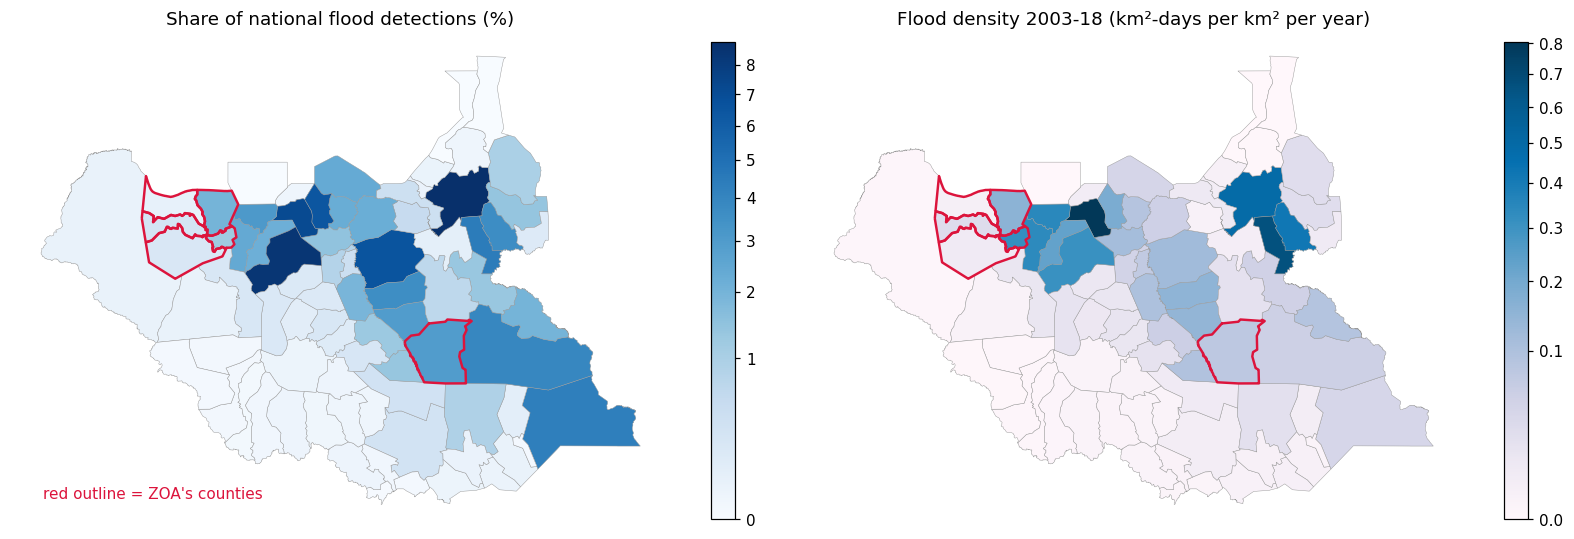

In [ ]:
g = a2.set_index("adm2_name").join(county[["mean share (%)", "density"]])
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, col, ttl, cmap in [(axs[0], "mean share (%)", "Share of national flood detections (%)", "Blues"),
                           (axs[1], "density", "Flood density 2003-18", "PuBu")]:
    g.plot(column=col, ax=ax, cmap=cmap, legend=True, edgecolor="0.6", lw=0.3,
           norm=mcolors.PowerNorm(0.5, vmin=0, vmax=g[col].max()), legend_kwds={"shrink": 0.7})
    g.loc[ZOA].boundary.plot(ax=ax, color="crimson", lw=1.6)
    ax.set_title(ttl); ax.set_axis_off()
axs[0].text(24.2, 3.6, "red outline = ZOA's counties", color="crimson")
fig.tight_layout(); fig.savefig(FIG / "02_county_flooding.png", bbox_inches="tight")

peak month per state: {'Northern Bahr el Ghazal': 'Oct', 'Warrap': 'Nov', 'Eastern Equatoria': 'Dec', 'Jonglei': 'Jan', 'Lakes': 'Jan', 'Unity': 'Jan', 'Upper Nile': 'Jan'}


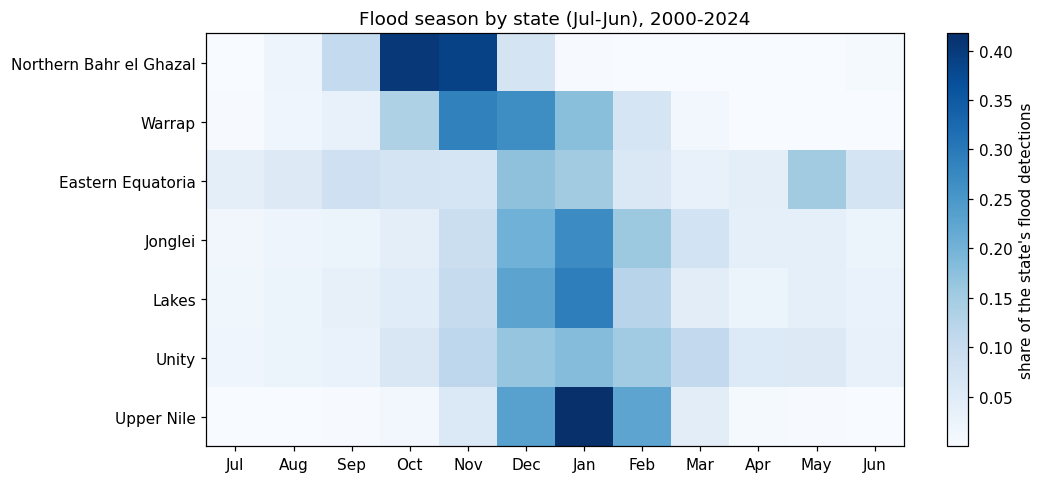

In [ ]:

st = c.groupby(["adm1_name", "month"]).pixeldays.sum().unstack().reindex(columns=wy_order).fillna(0)
st = st[st.sum(axis=1) > st.sum(axis=1).sum() * 0.01]
st_share = st.div(st.sum(axis=1), axis=0)
st_share = st_share.loc[st_share.idxmax(axis=1).map(wy_order.index).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(st_share.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(12), wy_labels); ax.set_yticks(range(len(st_share)), st_share.index)
fig.colorbar(im, ax=ax, label="share of the state's flood detections")
ax.set_title("Flood season by state (Jul-Jun), 2000-2024")
fig.tight_layout(); fig.savefig(FIG / "02_state_flood_season.png", bbox_inches="tight")
print("peak month per state:", st_share.idxmax(axis=1).map(lambda m: months[m - 1]).to_dict())

The country does not flood all at the same time. North-west states peak earlier than the Sudd states.\
Northern Bahr el Ghazal peaks in october and Warrap in November, Jonglei, Unity, Lakes, Upper Nile all peak in January.\
If we try to use a single model for the whole country it would probably fail.

  victoria: cleaned series ends 2002-08-06 (329 passes) - mission-code bug in data_cleaning.load_lakes; using loading.load_lake_stations instead
  Kyoga: cleaned series ends 2002-07-27 (156 passes) - mission-code bug in data_cleaning.load_lakes; using loading.load_lake_stations instead
 victoria: 1992-10-07 to 2026-05-18, 1317 altimetry passes, median gap 10 days
    Kyoga: 1992-09-27 to 2026-05-18, 1007 altimetry passes, median gap 10 days
   Albert: 2002-07-10 to 2026-04-25, 850 altimetry passes, median gap 6 days

annual mean level, change 2015-18 -> 2020-24 (m): {'Victoria': 0.87, 'Kyoga': 1.83, 'Albert': 2.14}
seasonal amplitude (m): {'Victoria': 0.34, 'Kyoga': 0.33, 'Albert': 0.5}


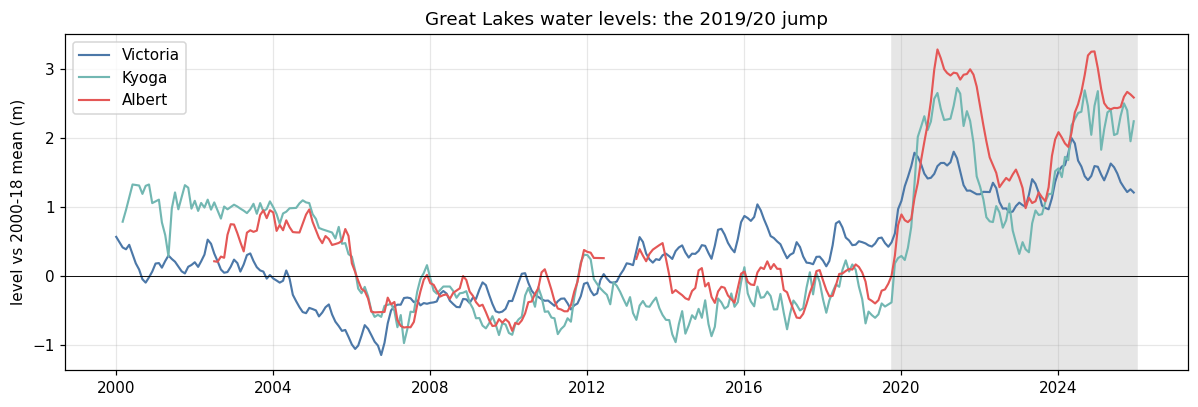

In [ ]:
lakes_raw = load_lakes()
lakes = pd.DataFrame({
    "Victoria": lakes_raw["victoria"].resample("MS").mean(),
    "Kyoga": lakes_raw["Kyoga"].resample("MS").mean(),
    "Albert": lakes_raw["Albert"].resample("MS").mean(),
}).loc["2000":"2025"]
for k, v in lakes_raw.items():
    idx = v.index
    print(f"{k:>9}: {idx.min().date()} to {idx.max().date()}, {len(v)} altimetry passes, "
          f"median gap {idx.to_series().diff().dt.days.median():.0f} days")

anom = lakes - lakes.loc["2000":"2018"].mean()
fig, ax = plt.subplots(figsize=(11, 3.8))
for k, col in zip(anom, ["#4c78a8", "#72b7b2", "#e45756"]):
    ax.plot(anom.index, anom[k].interpolate(limit=3), label=k, color=col, lw=1.4)
ax.axhline(0, color="k", lw=0.6); ax.axvspan(pd.Timestamp("2019-10-01"), pd.Timestamp("2025-12-31"), color="0.9", zorder=0)
ax.set_ylabel("level vs 2000-18 mean (m)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Great Lakes water levels: the 2019/20 jump")
fig.tight_layout(); fig.savefig(FIG / "02_lake_levels.png", bbox_inches="tight")

ann_lake = lakes.groupby(lakes.index.year).mean()
print("\nannual mean level, change 2015-18 -> 2020-24 (m):",
      (ann_lake.loc[2020:2024].mean() - ann_lake.loc[2015:2018].mean()).round(2).to_dict())
print("seasonal amplitude (m):", (lakes.groupby(lakes.index.month).mean().max() - lakes.groupby(lakes.index.month).mean().min()).round(2).to_dict())

In [ ]:

SUDD = ["Jonglei", "Unity", "Lakes", "Upper Nile"]
season = pd.DataFrame({
    "sudd_share": c[c.adm1_name.isin(SUDD)].groupby("wy").pixeldays.sum() / nat,
    "persistence": c[c.month.isin([3, 4, 5, 6])].groupby("wy").pixeldays.sum() / nat,
})

pre = lakes[lakes.index.month <= 6]
season = season.join(pre.groupby(pre.index.year).mean()).dropna()

detrend = lambda s: s - np.polyval(np.polyfit(s.index, s, 1), s.index)
def corr_table(df, xs, ys, periods):
    rows = []
    for x in xs:
        for y in ys:
            for lab, (a, b) in periods.items():
                d = df.loc[a:b, [x, y]].dropna()
                r, p = stats.spearmanr(d[x], d[y]); rd, pd_ = stats.spearmanr(detrend(d[x]), detrend(d[y]))
                rows.append({"driver": x, "flood measure": y, "seasons": lab, "n": len(d),
                             "raw rho": r, "raw p": p, "detrended rho": rd, "detrended p": pd_})
    return pd.DataFrame(rows)

lake_corr = corr_table(season, ["Victoria", "Kyoga", "Albert"], ["sudd_share", "persistence"],
                       {"2002-2024": (2002, 2024), "2003-2018": (2003, 2018)})
lake_corr.round(2)

,driver,flood measure,seasons,n,raw rho,raw p,detrended rho,detrended p
0,Victoria,sudd_share,2002-2024,22,0.53,0.01,-0.04,0.86
1,Victoria,sudd_share,2003-2018 (MODIS only),16,0.14,0.60,-0.19,0.48
2,Victoria,persistence,2002-2024,22,0.51,0.02,0.33,0.14
3,Victoria,persistence,2003-2018 (MODIS only),16,0.05,0.85,0.37,0.16
4,Kyoga,sudd_share,2002-2024,22,0.37,0.09,0.25,0.26
5,Kyoga,sudd_share,2003-2018 (MODIS only),16,0.06,0.84,0.06,0.83
6,Kyoga,persistence,2002-2024,22,0.55,0.01,0.59,0.00
7,Kyoga,persistence,2003-2018 (MODIS only),16,0.22,0.42,0.41,0.11
8,Albert,sudd_share,2002-2024,22,0.52,0.01,0.32,0.15
9,Albert,sudd_share,2003-2018 (MODIS only),16,0.24,0.38,0.14,0.62


The lake levels rose suddenly in 2019/2020. Albert by about 2.1 meters, Kyoga by 1.8 and Victoria by 0.9 Meters. It does coincide with the recorded 2020-2022 floods.\
Over the full record from 2002 to 2024. all three lakes correlated with the Sudd's flood but the tests show that this is not robust.\
Victoria and Sudd correlation collapses under detrending from 0.53 to -0.05.\
Kyoga and Albert with persistance correlation survives detrending but within the 2003-2018 season before the spike in detections the relationship is not significant.\
So most of the correlations are in the 2020-2024 period where the lake levels increasesd but also detections. We cannot separate the two.

13 rows in information.xlsx, 12 distinct stations (station [100205] is listed twice, once as South Sudan, once as Sudan)


,station nr,area id,Country,latitude,longitude,in South Sudan,mean Q (m3/s),peak month,seasonal range / mean
0,334,100205,South Sudan,9.6,31.6,True,5401.83,Apr,0.06
1,224,1541,Sudan,12.4,32.8,False,6616.26,Aug,0.19
2,225,1542,Sudan,13.9,32.4,False,5758.89,Aug,0.59
3,226,1543,Sudan,14.9,32.2,False,6437.22,Mar,0.07
4,227,1544,Sudan,13.1,33.9,False,1924.51,Aug,1.17
5,228,1545,Sudan,13.8,33.6,False,2251.20,Aug,0.73
6,229,1547,Sudan,15.6,32.4,False,6617.71,Sep,0.69
7,230,1548,Sudan,16.6,32.9,False,9333.18,Sep,1.17
8,289,11808,Sudan,18.8,32.0,False,11035.81,Nov,0.04
9,290,11842,Sudan,21.5,31.0,False,10342.88,Jul,0.19


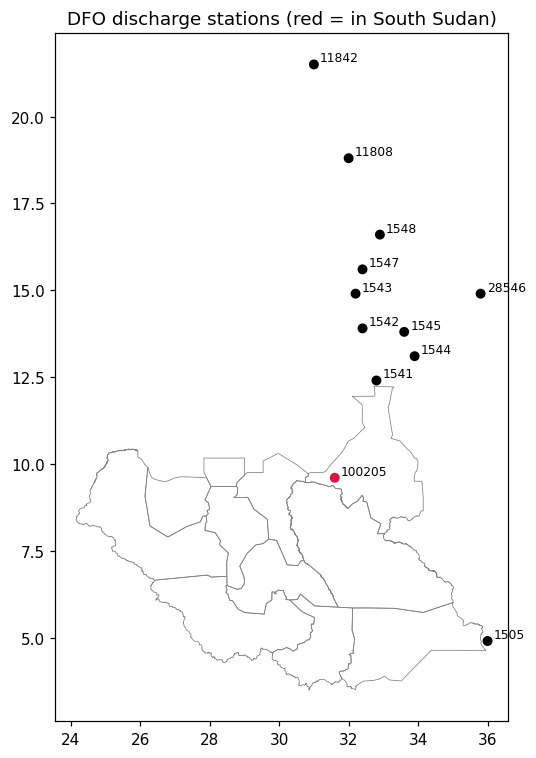

In [ ]:
dis, info = load_discharge()
print(f"{len(info)} rows in information.xlsx, {info['area id'].nunique()} distinct stations "
      f"(station {info['area id'][info['area id'].duplicated()].tolist()} is listed twice, once as South Sudan, once as Sudan)")
info = info.drop_duplicates("area id")
info["in South Sudan"] = gpd.points_from_xy(info.longitude, info.latitude).within(a0.geometry.iloc[0])
info["mean Q (m3/s)"] = info["area id"].map(lambda k: dis[k].iloc[:, 0].mean())
info["peak month"] = info["area id"].map(lambda k: months[dis[k].iloc[:, 0].groupby(dis[k].index.month).mean().idxmax() - 1])
info["seasonal range / mean"] = info["area id"].map(
    lambda k: (lambda m: (m.max() - m.min()) / m.mean())(dis[k].iloc[:, 0].groupby(dis[k].index.month).mean()))

fig, ax = plt.subplots(figsize=(6, 7))
a1.boundary.plot(ax=ax, color="0.5", lw=0.5)
ax.scatter(info.longitude, info.latitude, c=np.where(info["in South Sudan"], "crimson", "k"), s=30, zorder=3)
for _, r in info.iterrows():
    ax.annotate(r["area id"], (r.longitude, r.latitude), xytext=(4, 2), textcoords="offset points", fontsize=8)
ax.set_title("DFO discharge stations (red = in South Sudan)"); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(FIG / "02_discharge_stations.png", bbox_inches="tight")
info.round(2)

Only Malakal station is inside South sudan, the rest are downstream from the Nile.

monthly mean range: 5237-5555 m³/s (seasonal range = 6% of the mean)
annual mean 2000-20: 5540 m³/s;  2021-25: 4771 m³/s
days with an exactly repeated value: 3.4%


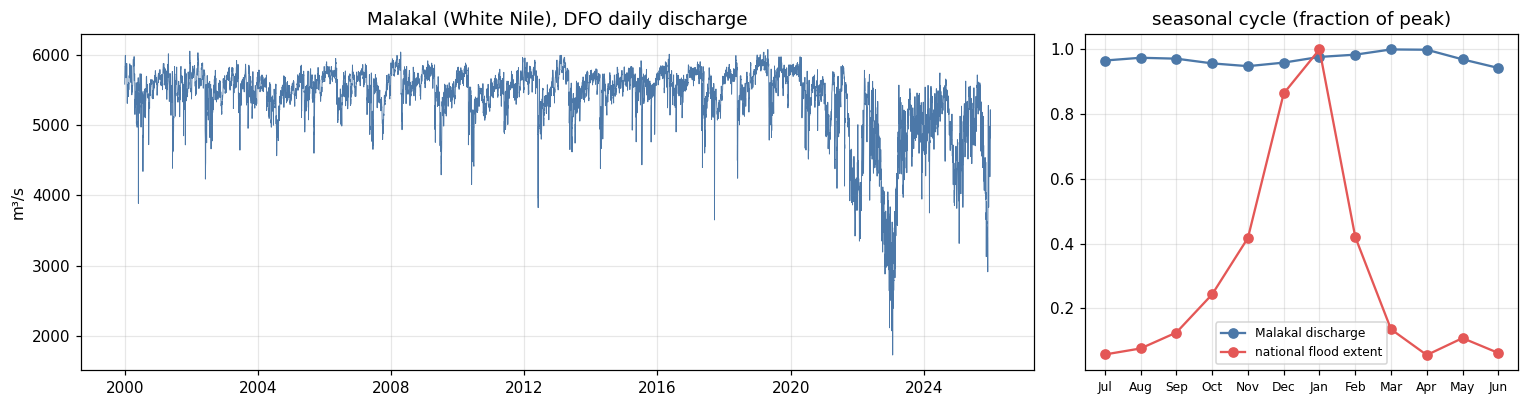

In [ ]:
q = dis[100205].iloc[:, 0].rename("Malakal").loc["2000":"2025"]
qm = q.resample("MS").mean()
fig, axs = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [2.2, 1]})
axs[0].plot(q.index, q, lw=0.6, color="#4c78a8"); axs[0].set_ylabel("m³/s"); axs[0].grid(alpha=0.3)
axs[0].set_title("Malakal (White Nile), DFO daily discharge")
clim_q = q.groupby(q.index.month).mean().reindex(wy_order)
clim_f = share.mean().reindex(wy_order)
axs[1].plot(range(12), clim_q / clim_q.max(), marker="o", label="Malakal discharge", color="#4c78a8")
axs[1].plot(range(12), clim_f / clim_f.max(), marker="o", label="national flood extent", color="#e45756")
axs[1].set_xticks(range(12), wy_labels, fontsize=8); axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
axs[1].set_title("seasonal cycle (fraction of peak)")
fig.tight_layout(); fig.savefig(FIG / "02_malakal_discharge.png", bbox_inches="tight")

ann_q = q.groupby(q.index.year).mean()
print(f"monthly mean range: {q.groupby(q.index.month).mean().min():.0f}-{q.groupby(q.index.month).mean().max():.0f} m³/s "
      f"(seasonal range = {(lambda m: (m.max()-m.min())/m.mean())(q.groupby(q.index.month).mean()):.0%} of the mean)")
print(f"annual mean 2000-20: {ann_q.loc[:2020].mean():.0f} m³/s;  2021-25: {ann_q.loc[2021:].mean():.0f} m³/s")
print(f"days with an exactly repeated value: {(q.diff() == 0).mean():.1%}")

Malakal only has 6% seasonal range, peaking in April.\
The mean drops from 2000-2020 to 2021-2025 exactly when the lakes and floods are the highest.\
This discharge is estimated from the satellite, cannot measure flow.

In [ ]:
season["Malakal"] = ann_q
dis_corr = corr_table(season, ["Malakal"], ["sudd_share", "persistence"],
                      {"2002-2024": (2002, 2024), "2003-2018 (MODIS only)": (2003, 2018)})
print("Malakal annual discharge vs lake levels (2002-2024, Spearman):",
      season[["Malakal", "Victoria", "Albert"]].corr("spearman").loc["Malakal", ["Victoria", "Albert"]].round(2).to_dict())
dis_corr.round(2)

Malakal annual discharge vs lake levels (2002-2024, Spearman): {'Victoria': -0.19, 'Albert': -0.34}


,driver,flood measure,seasons,n,raw rho,raw p,detrended rho,detrended p
0,Malakal,sudd_share,2002-2024,22,-0.27,0.22,-0.32,0.14
1,Malakal,sudd_share,2003-2018 (MODIS only),16,0.05,0.85,-0.03,0.91
2,Malakal,persistence,2002-2024,22,-0.52,0.01,-0.71,0.00
3,Malakal,persistence,2003-2018 (MODIS only),16,-0.25,0.34,-0.17,0.52


The only significant correlation is negative.\
Malakal is not positively related to the lake levels that feed it.\
We cannot use Discharge as a predictor.

national mean annual ET0: 2095 mm vs rainfall 895 mm
cells with annual surplus (P > ET0): 8 of 838


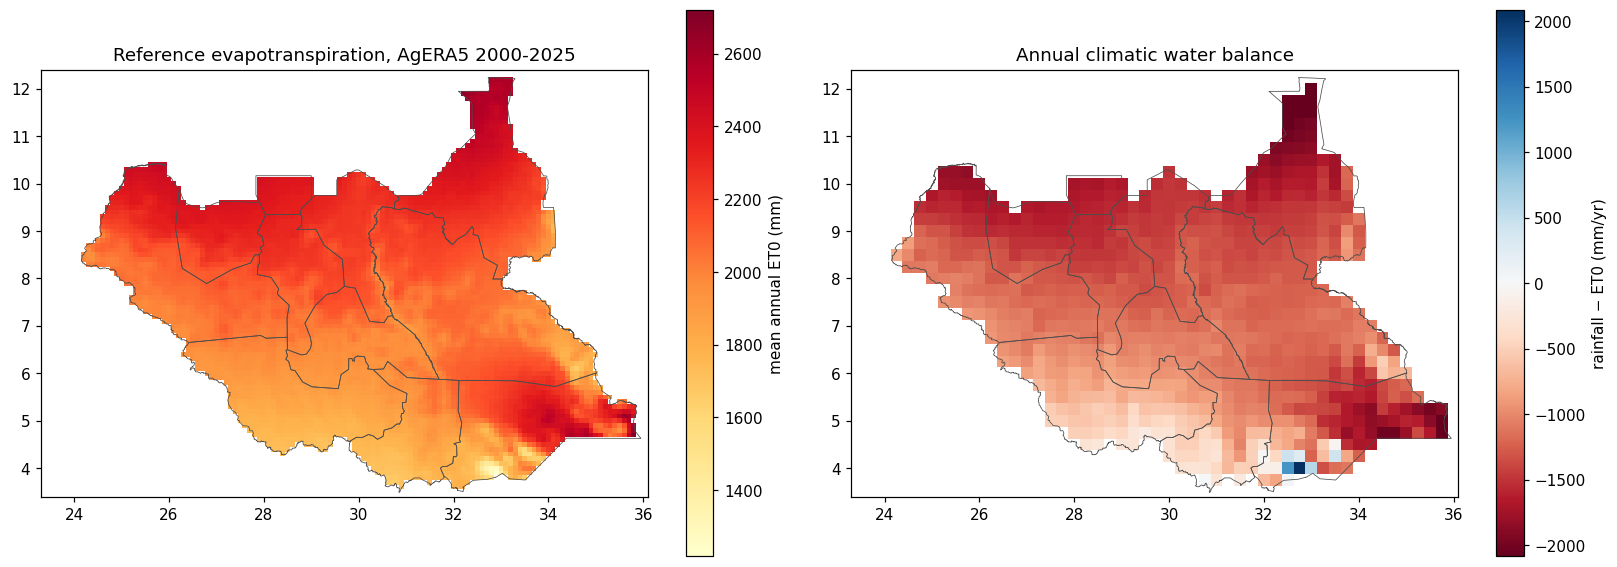

In [ ]:
et = xc.et0_monthly()
lat_e, lon_e = et.latitude.values, et.longitude.values
LONe, LATe = np.meshgrid(lon_e, lat_e)
pe = gpd.GeoDataFrame(geometry=gpd.points_from_xy(LONe.ravel(), LATe.ravel()), crs=4326)
mask_e = np.zeros(LONe.size, bool); mask_e[gpd.sjoin(pe, a0[["geometry"]], predicate="within").index] = True
mask_e = mask_e.reshape(LONe.shape)

days_in = et.time.dt.days_in_month
et_month_mm = et * days_in
annual_et = np.where(mask_e, et_month_mm.groupby("time.year").sum().mean("year").values, np.nan)

w = np.cos(np.deg2rad(LATe)) * mask_e
et_nat = pd.Series((et_month_mm.values * w).sum((1, 2)) / w.sum(), index=pd.DatetimeIndex(et.time.values))
et_ym = et_nat.groupby([et_nat.index.year, et_nat.index.month]).sum().unstack()


annual_et_025 = et_month_mm.groupby("time.year").sum().mean("year").interp(latitude=lat, longitude=lon, method="nearest").values
balance = np.where(mask, annual_tp - annual_et_025, np.nan)

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
im = axs[0].pcolormesh(lon_e, lat_e, annual_et, cmap="YlOrRd", shading="nearest")
fig.colorbar(im, ax=axs[0], label="mean annual ET0 (mm)", shrink=0.8)
lim = np.nanpercentile(np.abs(balance), 99)
im = axs[1].pcolormesh(lon, lat, balance, cmap="RdBu", vmin=-lim, vmax=lim, shading="nearest")
fig.colorbar(im, ax=axs[1], label="rainfall − ET0 (mm/yr)", shrink=0.8)
for ax, ttl in zip(axs, ["Reference evapotranspiration 2000-2025", "Annual climatic water balance"]):
    a1.boundary.plot(ax=ax, color="0.3", lw=0.5); ax.set_title(ttl)
    ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(FIG / "02_et0_balance.png", bbox_inches="tight")
print(f"national mean annual: {et_ym.sum(axis=1).mean():.0f} mm vs rainfall {rain_ym.sum(axis=1).mean():.0f} mm")
print(f"cells with annual surplus: {(balance > 0).sum()} of {np.isfinite(balance).sum()}")

Evapotranspiration averages 2100 mm/year against around 900mm of rain.\
Only 8 cells have an annual surplus so the atmosphere supposedly can remove more water than falls.

            Jul    Aug    Sep    Oct    Nov    Dec    Jan    Feb    Mar    Apr    May    Jun
rainfall  149.0  168.0  132.0  112.0   33.0    5.0    2.0    4.0   21.0   61.0   95.0  111.0
ET0       138.0  137.0  141.0  152.0  165.0  196.0  216.0  209.0  221.0  195.0  177.0  149.0
P - ET0    11.0   32.0   -9.0  -39.0 -132.0 -191.0 -214.0 -205.0 -199.0 -134.0  -82.0  -37.0

ET0 trend: +36 mm/decade (p=0.000);  CV of annual ET0: 0.020


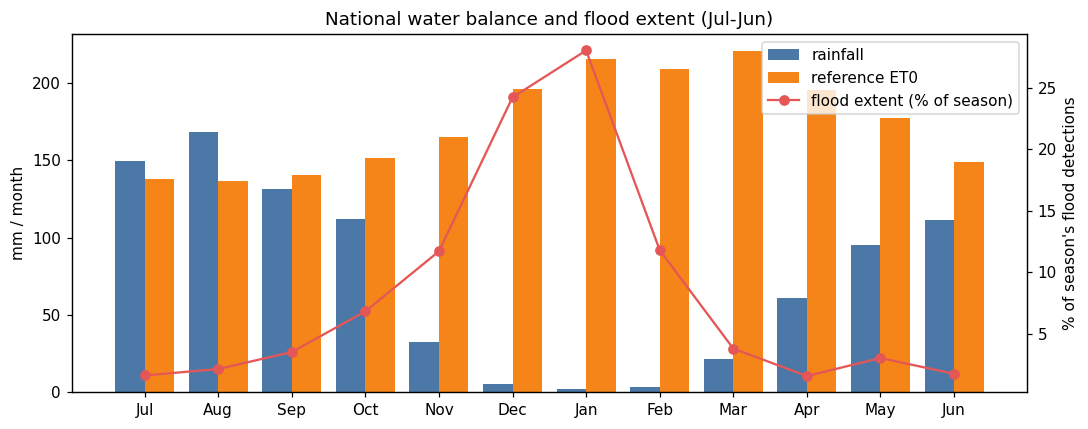

In [ ]:
wb = pd.DataFrame({"rainfall": rain_ym.mean(), "ET0": et_ym.mean()}).reindex(wy_order)
wb["P - ET0"] = wb.rainfall - wb.ET0
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(12)
ax.bar(x - 0.2, wb.rainfall, 0.4, label="rainfall", color="#4c78a8")
ax.bar(x + 0.2, wb.ET0, 0.4, label="reference ET0", color="#f58518")
ax2 = ax.twinx(); ax2.plot(x, share.mean().reindex(wy_order) * 100, color="#e45756", marker="o", label="flood extent (% of season)")
ax.set_xticks(x, wy_labels); ax.set_ylabel("mm / month"); ax2.set_ylabel("% of season's flood detections")
ax.set_title("National water balance and flood extent (Jul-Jun)")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "02_water_balance.png", bbox_inches="tight")
print(wb.round(0).T.rename(columns=dict(enumerate(months, 1))).to_string())
s = stats.linregress(et_ym.index, et_ym.sum(axis=1))
print(f"\nET0 trend: {s.slope*10:+.0f} mm/decade (p={s.pvalue:.3f});  CV of annual ET0: {et_ym.sum(axis=1).std()/et_ym.sum(axis=1).mean():.3f}")

Rain exceeds evapotranspiration only in July and August, but flood peaks in December-January when the deficit is the highest and there is almost no rain.\
This flood water cannot be sustained by local rain, this water has to come from upstream.\
Evapotranspiration barely changes between years.

population 2015: 11.1 M,  2020: 10.6 M,  2025: 12.1 M
people in frequently flooded cells: 195 k (1.8% of population)


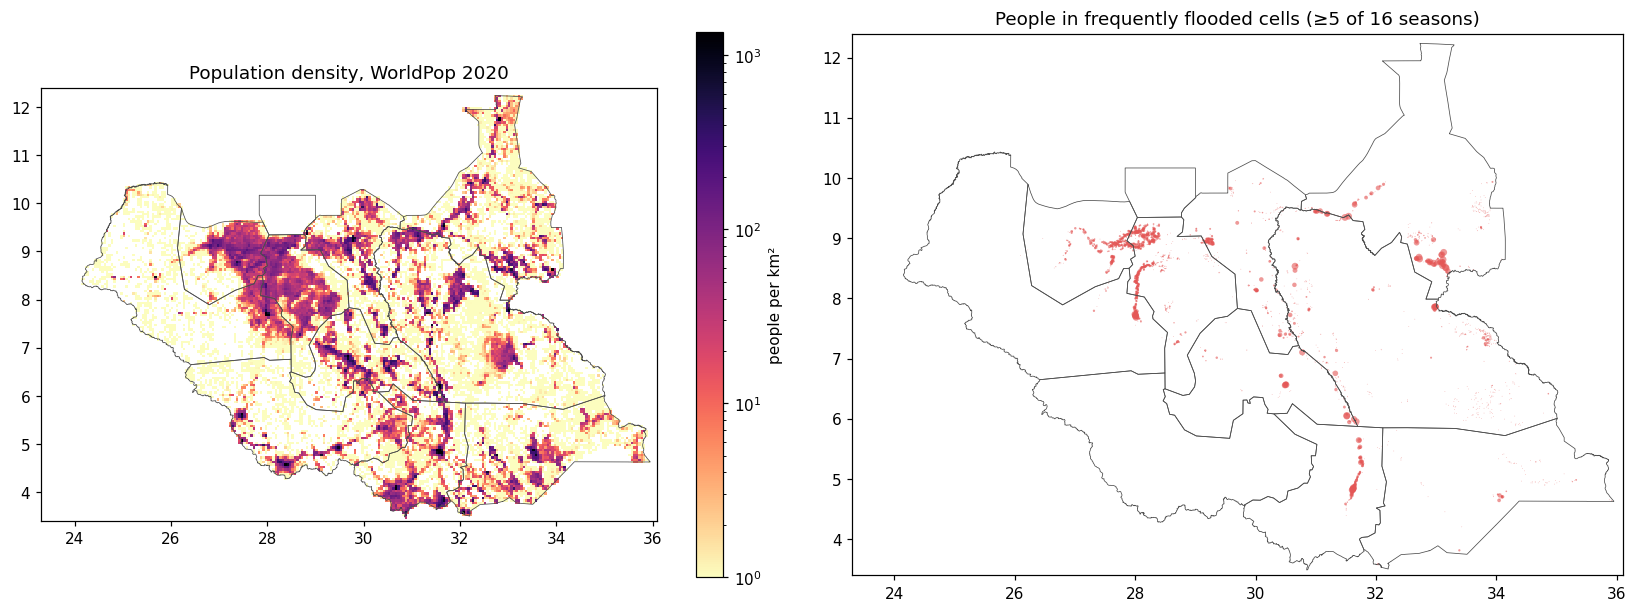

In [ ]:
pop = xc.population_cells(2020)
pop25, pop15 = xc.population_cells(2025), xc.population_cells(2015)
print(f"population 2015: {pop15['pop'].sum()/1e6:.1f} M,  2020: {pop['pop'].sum()/1e6:.1f} M,  2025: {pop25['pop'].sum()/1e6:.1f} M")

pc = pop.assign(clat=(np.floor(pop.cell_lat / coarse) * coarse + coarse / 2).round(3),
                clon=(np.floor(pop.cell_lon / coarse) * coarse + coarse / 2).round(3))
pgrid = pc.groupby(["clat", "clon"])["pop"].sum().unstack() / ((coarse * 111.32) ** 2 * np.cos(np.deg2rad(8)))

# flood frequency per 0.01 deg cell: number of MODIS-only seasons with any detection
mod = ssd[ssd.wy.between(2003, 2018)]
freq = mod.groupby(["cell_lat", "cell_lon"]).wy.nunique().rename("seasons_flooded").reset_index()
pop_f = pop.merge(freq, on=["cell_lat", "cell_lon"], how="left").fillna({"seasons_flooded": 0})
pop_f["exposed"] = pop_f.seasons_flooded >= 5

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
im = axs[0].pcolormesh(pgrid.columns, pgrid.index, pgrid.values, cmap="magma_r", shading="nearest",
                       norm=mcolors.LogNorm(vmin=1, vmax=np.nanpercentile(pgrid.values, 99.9)))
fig.colorbar(im, ax=axs[0], label="people per km²", shrink=0.8)
ex = pop_f[pop_f.exposed]
axs[1].scatter(ex.cell_lon, ex.cell_lat, s=np.clip(ex["pop"] / 50, 0.2, 20), c="#e45756", alpha=0.6, lw=0)
for ax, ttl in zip(axs, ["Population density, WorldPop 2020", "People in frequently flooded cells (≥5 of 16 seasons)"]):
    a1.boundary.plot(ax=ax, color="0.3", lw=0.5); ax.set_title(ttl)
    ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(FIG / "02_population_exposure.png", bbox_inches="tight")
print(f"people in frequently flooded cells: {ex['pop'].sum()/1e3:,.0f} k ({ex['pop'].sum()/pop['pop'].sum():.1%} of population)")

In [ ]:
expo = pop_f.groupby("adm2_name").agg(population=("pop", "sum"),
                                      exposed=("pop", lambda s: s[pop_f.loc[s.index, "exposed"]].sum()))
expo["exposed (%)"] = expo.exposed / expo.population * 100
expo["exposed rank"] = expo.exposed.rank(ascending=False).astype(int)
expo = expo.sort_values("exposed", ascending=False)
print(f"top 10 counties hold {expo.exposed.head(10).sum() / expo.exposed.sum():.0%} of exposed people")
display((expo.head(15) / [1e3, 1e3, 1, 1]).round(1).rename(columns={"population": "population (k)", "exposed": "exposed (k)"}))
print("ZOA's counties:")
display((expo.loc[ZOA] / [1e3, 1e3, 1, 1]).round(1).rename(columns={"population": "population (k)", "exposed": "exposed (k)"}))
print(f"ZOA's six counties: {expo.loc[ZOA, 'exposed'].sum()/1e3:,.0f} k exposed people "
      f"= {expo.loc[ZOA, 'exposed'].sum()/expo.exposed.sum():.0%} of the national total")

top 10 counties hold 67% of exposed people


,population (k),exposed (k),exposed (%),exposed rank
adm2_name,,,,
Gogrial West,282.3,19.4,6.9,1.0
Twic,233.4,19.2,8.2,2.0
Luakpiny/Nasir,243.0,17.4,7.1,3.0
Juba,462.4,16.3,3.5,4.0
Aweil East,292.4,12.2,4.2,5.0
Ulang,121.5,11.9,9.8,6.0
Wau,270.7,10.2,3.8,7.0
Awerial,131.0,9.1,6.9,8.0
Jur River,245.9,8.5,3.4,9.0


ZOA's counties:


,population (k),exposed (k),exposed (%),exposed rank
adm2_name,,,,
Aweil Centre,59.1,0.9,1.6,30.0
Aweil East,292.4,12.2,4.2,5.0
Aweil North,145.0,0.6,0.4,34.0
Aweil South,123.8,6.5,5.3,11.0
Aweil West,172.4,3.4,1.9,17.0
Bor South,278.6,1.0,0.4,28.0


ZOA's six counties: 25 k exposed people = 13% of the national total
